In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv ("/Users/kittnguyen/Documents/us-flight-project/data/raw_data/airports_geolocation.csv")
df

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447
...,...,...,...,...,...,...,...
359,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681
360,XWA,Williston Basin International Airport,Williston,ND,USA,48.14700,-103.61800
361,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023
362,YKM,Yakima Air Terminal,Yakima,WA,USA,46.56670,-120.53330


In [3]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  364 non-null    object 
 1   AIRPORT    364 non-null    object 
 2   CITY       364 non-null    object 
 3   STATE      364 non-null    object 
 4   COUNTRY    364 non-null    object 
 5   LATITUDE   364 non-null    float64
 6   LONGITUDE  364 non-null    float64
dtypes: float64(2), object(5)
memory usage: 20.0+ KB


In [4]:
df.describe ()

,LATITUDE,LONGITUDE
count,364.000000,364.000000
mean,38.810970,-96.809033
std,8.757505,27.471654
min,-14.278100,-176.646030
25%,33.672655,-110.788562
50%,39.251930,-93.743140
75%,43.113110,-82.501792
max,71.285450,145.733300


In [21]:
def classify_airport_type(airport_name):
    if 'International Airport' in airport_name:
        return 'Major_International'
    elif 'Regional Airport' in airport_name or 'Municipal Airport' in airport_name:
        return 'Regional_Spoke'
    else:
        return 'Other_Major_Hub'

df['Airport_Function_Type'] = df['AIRPORT'].apply(classify_airport_type)

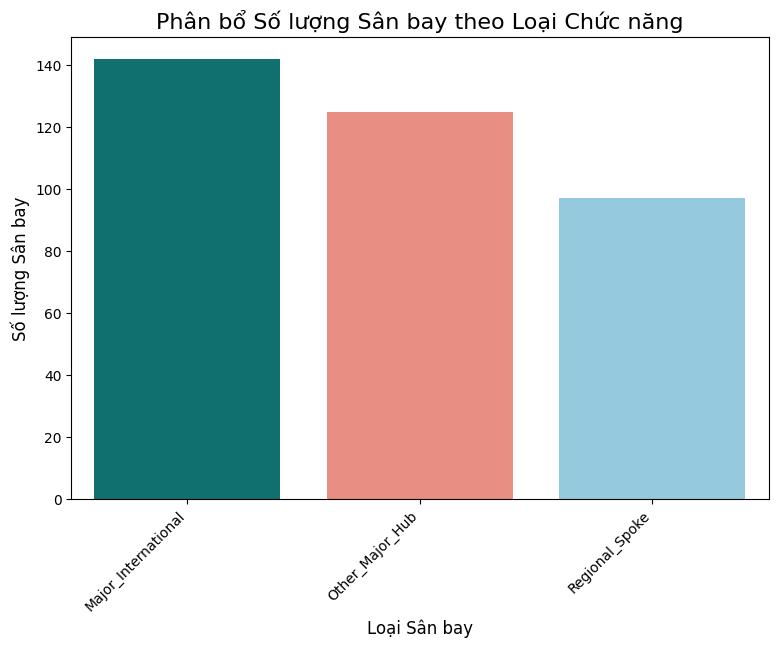

In [24]:
type_counts = df['Airport_Function_Type'].value_counts()

plt.figure(figsize=(9, 6))
sns.barplot(x=type_counts.index, y=type_counts.values, palette=['teal', 'salmon', 'skyblue'])

plt.title('Phân bổ Số lượng Sân bay theo Loại Chức năng', fontsize=16)
plt.xlabel('Loại Sân bay', fontsize=12)
plt.ylabel('Số lượng Sân bay', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


Major_International: Các sân bay này thường có thời gian quay vòng (turnaround time) dài hơn do cần xử lý Hải quan và An ninh quốc tế. Điều này làm tăng rủi ro Trễ Do Hãng Bay (Delay_Carrier) nếu lịch trình bị rút ngắn.

Regional_Spoke: Mặc dù ít bận rộn hơn, các sân bay khu vực này thường là điểm cuối của các chuyến bay ngắn và có nguồn lực hạn chế (ít cửa ra, ít máy bay dự phòng), khiến chúng dễ bị ảnh hưởng bởi hiệu ứng Domino từ các Hub lớn.

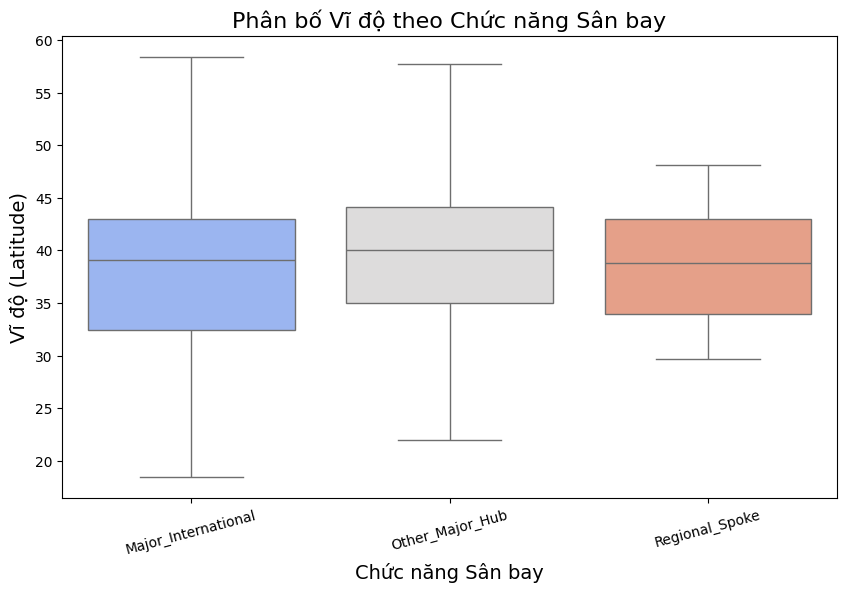

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Airport_Function_Type', 
    y='LATITUDE', 
    data=df, 
    palette='coolwarm',
    order=['Major_International', 'Other_Major_Hub', 'Regional_Spoke'],
    showfliers=False
)

plt.title('Phân bố Vĩ độ theo Chức năng Sân bay', fontsize=16)
plt.xlabel('Chức năng Sân bay', fontsize=14)
plt.ylabel('Vĩ độ (Latitude)', fontsize=14)
plt.xticks(rotation=15)
plt.show()

Hub Quốc tế (Major_International) nằm xa về phía Bắc: Nhóm sân bay Major_International có phân bố Vĩ độ cao nhất.Có thể thấy, Hub Quốc tế quan trọng nhất của Mỹ có xu hướng nằm ở các vĩ độ cao hơn, nghĩa là chúng hoạt động trong điều kiện khí hậu lạnh hơn (có nguy cơ cao hơn về tuyết, băng, và nhu cầu khử băng) so với các Hub nhỏ hơn hoặc các sân bay khu vực.

Độ biến thiên: Phân bố của nhóm Major_International cũng rộng hơn, nhưng giá trị cốt lõi của chúng vẫn nằm cao hơn. Điều này xác nhận rằng các sân bay quan trọng nhất đang đối mặt với các thách thức hoạt động tiềm năng cao nhất do yếu tố khí hậu.

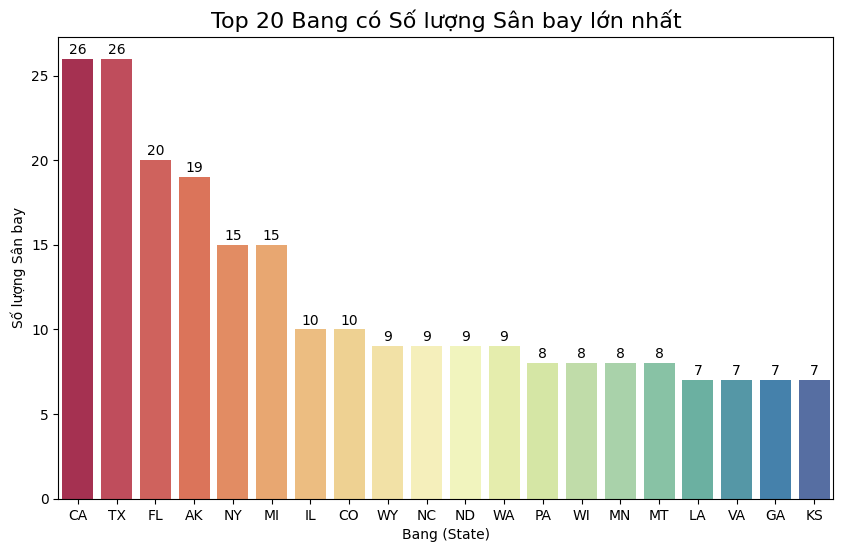

In [13]:
state_airport_counts = df['STATE'].value_counts().reset_index()
state_airport_counts.columns = ['STATE', 'Airport_Count']

df_geo = df.merge(state_airport_counts, on='STATE', how='left')

top_20_dense_states = state_airport_counts.head(20)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='STATE', 
    y='Airport_Count', 
    data=top_20_dense_states, 
    palette='Spectral'
)
for p in ax.patches:
    height = p.get_height ()
    if height > 0:
        ax.text (
            p.get_x () + p.get_width ()/2,
            height + 0.3,
            int (height),
            ha='center'
        )
ax.set_title('Top 20 Bang có Số lượng Sân bay lớn nhất', fontsize=16)
ax.set_xlabel('Bang (State)')
ax.set_ylabel('Số lượng Sân bay')
plt.show()


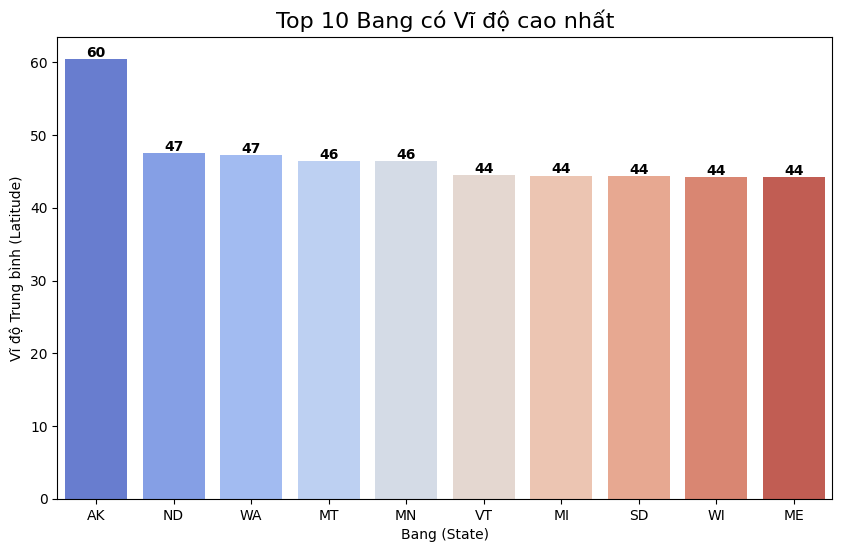

In [27]:
state_latitude = df_geo.groupby('STATE')['LATITUDE'].mean().reset_index()
state_latitude_sorted = state_latitude.sort_values(by='LATITUDE', ascending=False)

top_10_cold_risk = state_latitude_sorted.head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='STATE', 
    y='LATITUDE', 
    data=top_10_cold_risk, 
    palette='coolwarm'
)
for p in ax.patches:
    height = p.get_height ()
    if height > 0:
        ax.text (
            p.get_x () + p.get_width ()/2,
            height + 0.3,
            int (height),
            ha='center',
            weight="bold"
        )
ax.set_title('Top 10 Bang có Vĩ độ cao nhất', fontsize=16)
ax.set_xlabel('Bang (State)')
ax.set_ylabel('Vĩ độ Trung bình (Latitude)')
plt.show()

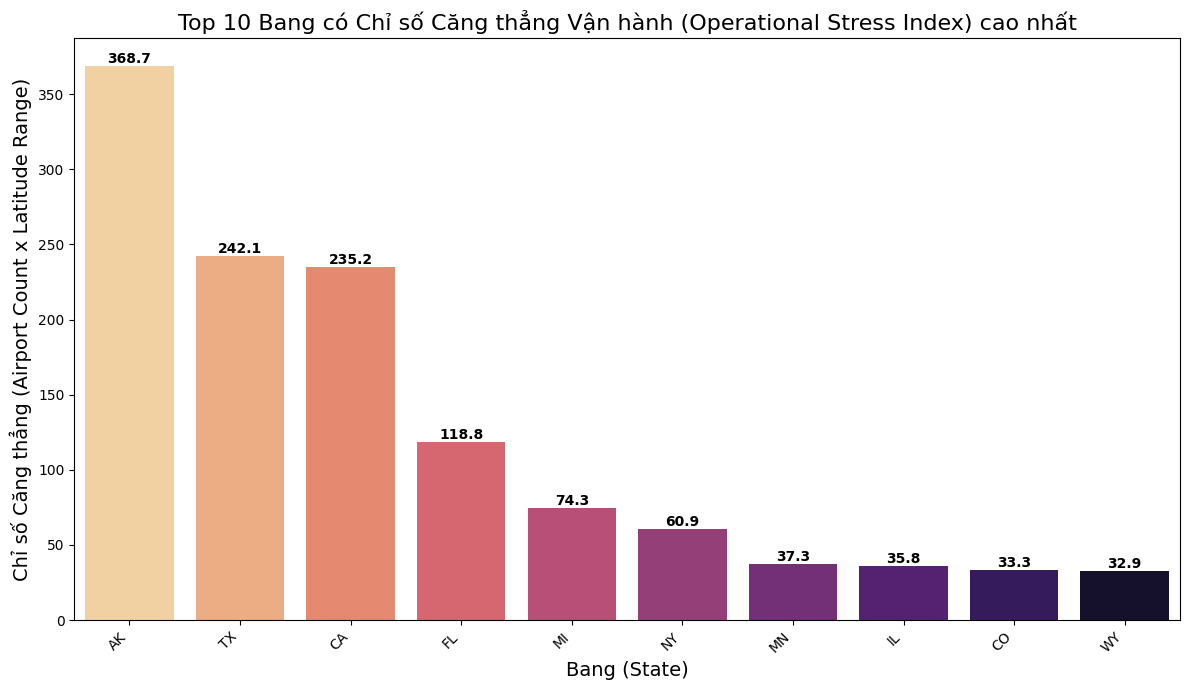

In [26]:
state_lat_range = df_geo.groupby('STATE')['LATITUDE'].agg(['min', 'max']).reset_index()
state_lat_range['Latitude_Range'] = state_lat_range['max'] - state_lat_range['min']

state_airport_counts = df_geo.groupby('STATE').size().reset_index(name='Airport_Count')

df_stress = state_lat_range[['STATE', 'Latitude_Range']].merge(state_airport_counts, on='STATE', how='left')

df_stress['Operational_Stress_Index'] = df_stress['Airport_Count'] * df_stress['Latitude_Range']

top_stress = df_stress.sort_values('Operational_Stress_Index', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='STATE', 
    y='Operational_Stress_Index', 
    data=top_stress, 
    palette='magma_r' 
)

for index, row in top_stress.reset_index().iterrows():
    plt.text(
        index, 
        row['Operational_Stress_Index'], 
        f"{row['Operational_Stress_Index']:.1f}", 
        color='black', 
        ha="center", 
        va='bottom' if row['Operational_Stress_Index'] > 0 else 'top',
        fontsize=10,
        weight='bold'
    )

plt.title('Top 10 Bang có Chỉ số Căng thẳng Vận hành (Operational Stress Index) cao nhất', fontsize=16)
plt.xlabel('Bang (State)', fontsize=14)
plt.ylabel('Chỉ số Căng thẳng (Airport Count x Latitude Range)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Alaska (AK): Chỉ số 368.7 cao hơn gấp rưỡi so với Bang đứng thứ hai. Nguyên nhân là do Phạm vi Vĩ độ (19.4) quá lớn, rủi ro thời tiết tăng theo cấp số nhân mạnh dẫn đến khả năng trễ cao.

Texas (TX) & California (CA): dẫn đầu về Mật độ Phức tạp Không phận (26 sân bay mỗi Bang) và có quy mô Vĩ độ rộng.Phải quản lý không phận chứa 26 điểm hoạt động, làm tăng rủi ro xung đột không phận (airspace conflict) và yêu cầu Kiểm soát Không lưu (ATC) hoạt động ở mức căng thẳng cao nhất. Sự cố xảy ra ở Hubs sẽ kéo dài và lan truyền độ trễ qua một khu vực rộng, gây khó khăn cho việc sử dụng các sân bay dự phòng và điều phối đường bay.

In [ ]:
def plot_airport_density_vs_latitude(df_geo):
    """
    Vẽ biểu đồ tương quan giữa số lượng sân bay và vĩ độ trung bình của mỗi bang bằng Plotly.
    """
    state_airport_counts = df_geo['STATE'].value_counts().reset_index()
    state_airport_counts.columns = ['STATE', 'Airport_Count']

    state_latitude = df_geo.groupby('STATE')['LATITUDE'].mean().reset_index()

    risk_analysis_df = state_airport_counts.merge(state_latitude, on='STATE', how='inner')

    high_risk_states = ['CA', 'TX', 'NY', 'FL', 'IL', 'AK', 'MN', 'MA', 'NJ', 'ME', 'ND']

    fig = px.scatter(
        risk_analysis_df,
        x='Airport_Count',
        y='LATITUDE',
        size='Airport_Count',
        color='LATITUDE',
        hover_name='STATE',
        color_continuous_scale='Viridis',
        size_max=50,
        opacity=0.75,
        title='Tương quan giữa Mật độ Sân bay và Vĩ độ Trung bình của Bang',
        labels={
            'Airport_Count': 'Số lượng Sân bay trong Bang',
            'LATITUDE': 'Vĩ độ Trung bình của Bang'
        }
    )

    # Gắn nhãn cho các bang có Airport_Count > 15 hoặc nằm trong danh sách high_risk_states 
    annotations = []
    for _, row in risk_analysis_df.iterrows():
        if row['STATE'] in high_risk_states or row['Airport_Count'] > 15:
            annotations.append(
                dict(
                    x=row['Airport_Count'],
                    y=row['LATITUDE'],
                    text=row['STATE'],
                    xanchor='left',
                    yanchor='middle',
                    showarrow=False,
                    font=dict(size=11, color='black', family='Arial')  # 👈 bỏ bold=True
                )
            )

    fig.update_layout(
        annotations=annotations,
        xaxis=dict(title='Số lượng Sân bay trong Bang'),
        yaxis=dict(title='Vĩ độ Trung bình của Bang'),
        coloraxis_colorbar=dict(title='Vĩ độ'),
        template='plotly_white',
        width=950,
        height=600,
        margin=dict(t=80, l=60, r=60, b=60)
    )
    fig.show()
    
plot_airport_density_vs_latitude(df_geo)

Các Bang như TX, CA, FL có số lượng sân bay (lưu lượng tiềm năng) rất lớn, tạo ra rủi ro NAS/Vận hành cao nhưng lại có vĩ độ thấp, giảm thiểu rủi ro tuyết/băng.

Rủi ro Khí hậu Cao (Góc Trên Trái/Giữa): Các Bang như MN, ME có vĩ độ rất cao, tạo ra rủi ro Thời tiết cực lớn (ví dụ: mùa đông) mặc dù không có quá nhiều sân bay.

Các Bang như IL , NY , AK nằm ở vị trí vừa có số lượng sân bay lớn, vừa có vĩ độ tương đối cao. Đây là những nơi sự tương tác giữa tắc nghẽn và thời tiết có thể gây ra sự cố trễ lan rộng nhất.

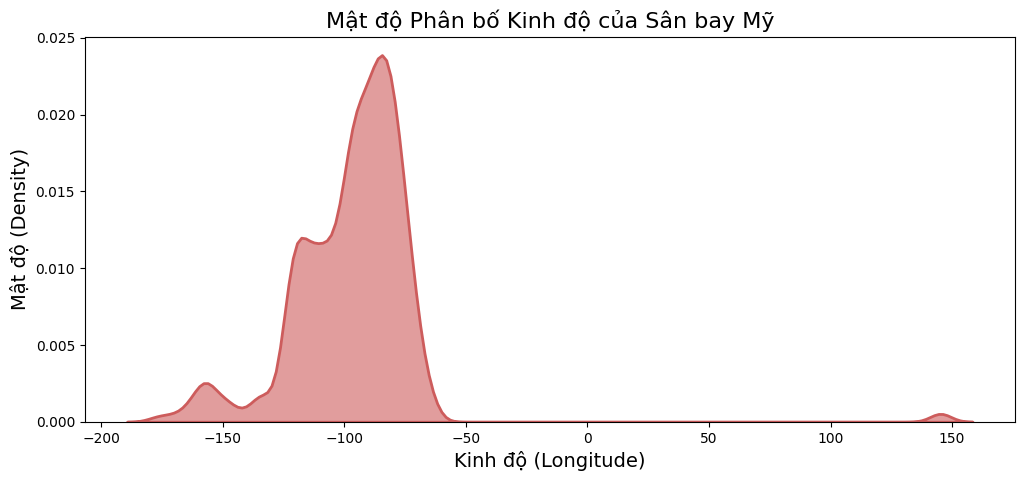

In [25]:
plt.figure(figsize=(12, 5))
sns.kdeplot(
    df_geo['LONGITUDE'], 
    fill=True, 
    color='indianred', 
    alpha=0.6,
    linewidth=2,
    bw_adjust=.5
)

plt.title('Mật độ Phân bố Kinh độ của Sân bay Mỹ', fontsize=16)
plt.xlabel('Kinh độ (Longitude)', fontsize=14)
plt.ylabel('Mật độ (Density)', fontsize=14)
plt.show()

Đỉnh lớn nhất ở khoảng -80° đến -90° (Phía Đông/Trung tâm: New York, Chicago, Atlanta).

Đỉnh thứ hai ở khoảng -115° đến -120° (Bờ Tây: California, Seattle).

Hệ thống sân bay Mỹ có xu hướng tập trung ở hai bờ ven biển, với một lượng lớn sân bay ở Bờ Đông, phản ánh cấu trúc dân cư và thương mại. Khoảng trống giữa hai đỉnh này (vùng nội địa như Nevada, Utah, v.v.) có mật độ sân bay thấp hơn.

Hầu hết các chuyến bay dài phải bắt đầu hoặc kết thúc ở một trong hai đỉnh này, làm tăng tầm quan trọng của các chuyến bay xuyên lục địa và tính dễ bị ảnh hưởng của lịch trình khi có sự cố tại các đỉnh này (ví dụ: trễ ở New York dễ dàng ảnh hưởng đến Los Angeles).

In [30]:
conditions = [
    df_geo['AIRPORT'].str.contains('International Airport'), 
    df_geo['AIRPORT'].str.contains('Regional Airport') | df_geo['AIRPORT'].str.contains('Municipal Airport') 
]
choices = [
    'Major_International',
    'Regional_Spoke'
]
df_geo['Airport_Function_Type'] = np.select(conditions, choices, default='Other_Major_Hub')

major_hubs = df_geo[df_geo['Airport_Function_Type'].isin(['Major_International', 'Other_Major_Hub'])].copy()

city_volatility = major_hubs.groupby('CITY').agg(
    Latitude_Range=('LATITUDE', lambda x: x.max() - x.min()),
    Hub_Count=('IATA_CODE', 'count')
).reset_index()

city_volatility = city_volatility[city_volatility['Hub_Count'] > 1]

top_volatility = city_volatility.sort_values('Latitude_Range', ascending=False).head(5)

print("\nTop 5 Thành phố có Độ Biến động Vĩ độ Nội tại Cao nhất (mức phân tán theo trục Bắc–Nam của các sân bay lớn trong cùng một thành phố.)")
print(top_volatility.to_string(index=False))


Top 5 Thành phố có Độ Biến động Vĩ độ Nội tại Cao nhất (mức phân tán theo trục Bắc–Nam của các sân bay lớn trong cùng một thành phố.)
        CITY  Latitude_Range  Hub_Count
     Jackson        11.29615          2
    Columbus         7.48367          3
  Charleston         5.47450          2
  Wilmington         5.40811          2
Jacksonville         4.33510          2


Các thành phố như Jackson hay Columbus có Phạm vi Vĩ độ (Latitude_Range) rất lớn giữa các Hub nội tại. Ví dụ, Jackson có sự khác biệt lên tới 11.3 vĩ độ giữa hai sân bay lớn.
Ý nghĩa: Khi mô hình dự đoán độ trễ chỉ sử dụng một điểm dữ liệu thời tiết cho toàn bộ khu vực "Jackson", nó sẽ không chính xác. Sân bay ở vĩ độ thấp hơn có thể không có tuyết, trong khi sân bay ở vĩ độ cao hơn (cùng tên thành phố) lại bị ảnh hưởng nặng nề.

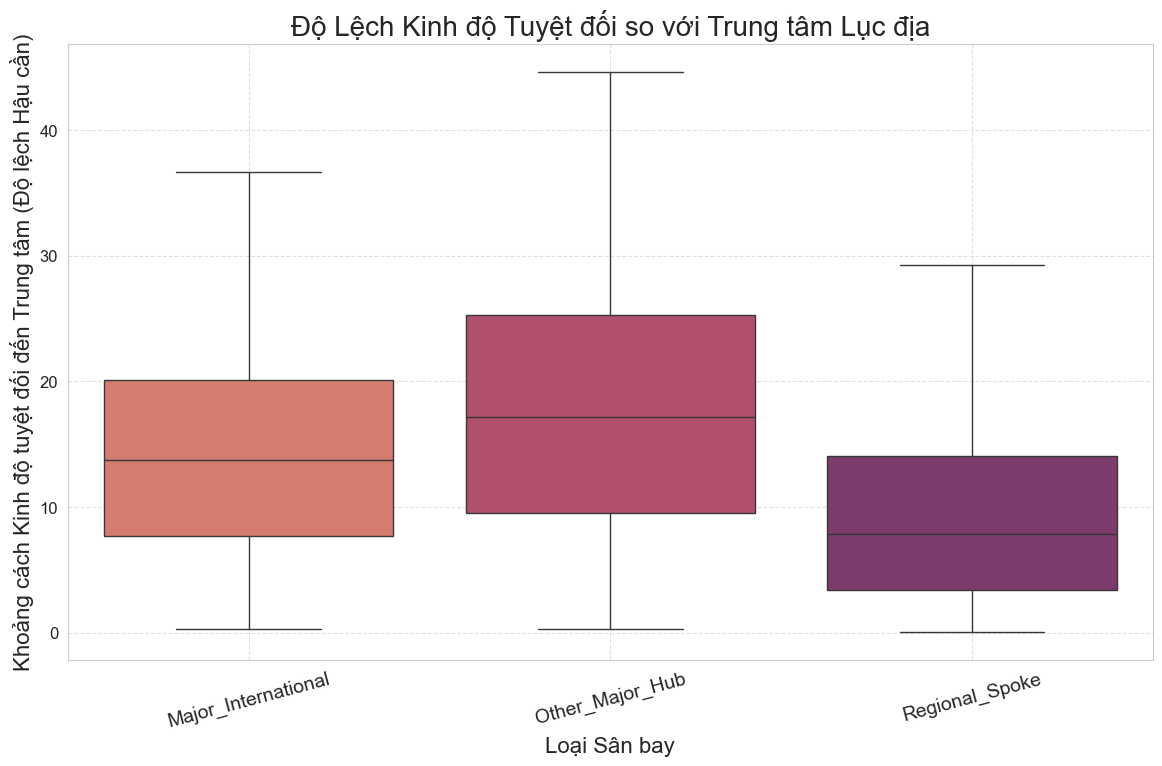


Độ Lệch Kinh độ Trung vị (Gần Trung tâm nhất)
Airport_Function_Type
Regional_Spoke          7.89
Major_International    13.74
Other_Major_Hub        17.15


In [32]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8) 

conditions = [
    df_geo['AIRPORT'].str.contains('International Airport'), 
    df_geo['AIRPORT'].str.contains('Regional Airport') | df_geo['AIRPORT'].str.contains('Municipal Airport') 
]
choices = [
    'Major_International',
    'Regional_Spoke'
]
df_geo['Airport_Function_Type'] = np.select(conditions, choices, default='Other_Major_Hub')

LON_CENTER_US = -95.0 

df_geo['Abs_Longitude_Deviation'] = (df_geo['LONGITUDE'] - LON_CENTER_US).abs()


plt.figure(figsize=(14, 8))
sns.boxplot(
    x='Airport_Function_Type', 
    y='Abs_Longitude_Deviation', 
    data=df_geo, 
    palette='flare',
    order=['Major_International', 'Other_Major_Hub', 'Regional_Spoke'],
    showfliers=False
)

plt.title('Độ Lệch Kinh độ Tuyệt đối so với Trung tâm Lục địa', fontsize=20)
plt.xlabel('Loại Sân bay', fontsize=16)
plt.ylabel('Khoảng cách Kinh độ tuyệt đối đến Trung tâm (Độ lệch Hậu cần)', fontsize=16)
plt.xticks(rotation=15, fontsize=14)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

median_dev = df_geo.groupby('Airport_Function_Type')['Abs_Longitude_Deviation'].median().round(2).sort_values()
print("\nĐộ Lệch Kinh độ Trung vị (Gần Trung tâm nhất)")
print(median_dev.to_string())

Trung tâm Hậu cần (Lowest Median): Nhóm sân bay có Giá trị Trung vị (Median) thấp nhất (hộp gần trục X nhất) là nhóm sân bay tập trung gần trung tâm lục địa nhất. Nhóm này có lợi thế về hậu cần và dễ dàng điều phối máy bay/phi hành đoàn đến bất kỳ bờ nào.

Độ ổn định (Narrowest Box): Hộp có Khoảng Tứ phân vị (IQR) hẹp nhất (mỏng nhất) cho thấy nhóm đó có sự phân bố tập trung nhất.

Nhóm Other_Major_Hub có độ lệch trung vị cao hơn đáng kể so với Hubs, điều đó có nghĩa là các Hub Khu vực này thường nằm ở rìa lục địa. Việc kết nối chúng với mạng lưới cốt lõi (Hubs) sẽ phức tạp và tốn kém hơn về mặt logistics, làm tăng rủi ro chuyến bay nối chuyến (connecting flight risk).
Vị trí tập trung của các Regional Spoke (7.89) là một lợi thế hậu cần lớn, nhưng điều này đồng thời tạo ra một rủi ro tập trung hóa (Centralization Risk). Khi một Hub lớn ở Bờ Đông bị tê liệt, sự gián đoạn sẽ ảnh hưởng đến một số lượng lớn các chuyến bay nối chuyến tập trung ở miền Trung.

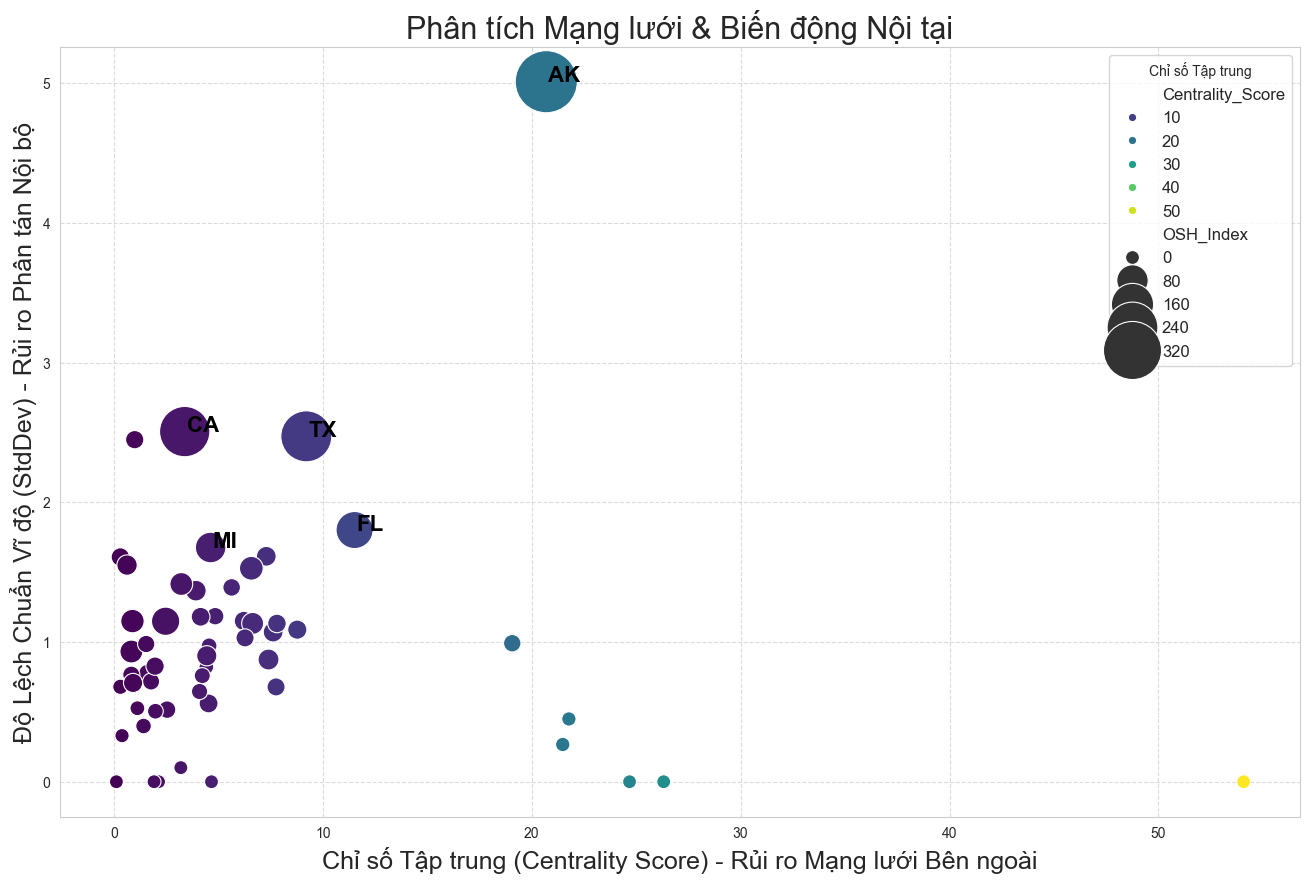

In [34]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10) 

US_LAT_CENTER = 39.8 

state_agg = df_geo.groupby('STATE').agg(
    Latitude_Mean=('LATITUDE', 'mean'), 
    Latitude_StdDev=('LATITUDE', 'std'), 
    Latitude_Range=('LATITUDE', lambda x: x.max() - x.min()),
    Airport_Count=('IATA_CODE', 'count')
).reset_index()

state_agg['Centrality_Score'] = (state_agg['Latitude_Mean'] - US_LAT_CENTER).abs()

state_agg['OSH_Index'] = state_agg['Airport_Count'] * state_agg['Latitude_Range']

state_agg['Latitude_StdDev'] = state_agg['Latitude_StdDev'].fillna(0)

plt.figure(figsize=(16, 10))

scatter = sns.scatterplot(
    x='Centrality_Score', 
    y='Latitude_StdDev', 
    size='OSH_Index',
    data=state_agg, 
    hue='Centrality_Score', 
    sizes=(100, 2000), 
    palette='viridis'
)

top_risk_states = state_agg.sort_values('OSH_Index', ascending=False).head(5)
for index, row in top_risk_states.iterrows():
    scatter.text(
        row['Centrality_Score'] + 0.1, 
        row['Latitude_StdDev'], 
        f"{row['STATE']}", 
        fontsize=16, 
        weight='bold',
        color='black'
    )

plt.title('Phân tích Mạng lưới & Biến động Nội tại', fontsize=22)
plt.xlabel('Chỉ số Tập trung (Centrality Score) - Rủi ro Mạng lưới Bên ngoài', fontsize=18)
plt.ylabel('Độ Lệch Chuẩn Vĩ độ (StdDev) - Rủi ro Phân tán Nội bộ', fontsize=18)
plt.legend(title='Chỉ số Tập trung', loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Centrality Score: khoảng cách tuyệt đối trung bình về vĩ độ của các sân bay trong một tiểu bang so với trung tâm vĩ độ lục địa Hoa Kỳ.
Std_Dev:  Đo mức độ phân tán của các sân bay theo chiều dọc (Bắc – Nam).

Trên bên phải: RỦI RO KÉP CAO NHẤT (Cô lập + Phân tán Nội bộ). Các Bang này được gán hệ số rủi ro cao nhất trong mô hình, chúng nằm xa trung tâm (phục hồi chậm) và có sự phức tạp nội bộ cao(dễ phát sinh độ trễ).
Dưới bên phải: Cô lập Mạng lưới Cao, Biến động Nội tại Thấp	Bang có rủi ro phục hồi cao nhưng dễ quản lý vận hành nội bộ.
Trên bên trái Tập trung Mạng lưới, biến động Nội tại Cao, bang nằm gần trung tâm (phục hồi nhanh) nhưng có rủi ro điều phối nội bộ phức tạp.